<h2>Formating of DB-Data<h2>

In [1]:
from hilfsfunktionen.formating import get_unchanged_table, get_formated_table, get_table_with_keys, create_n_sentences
df_collection = {}
df_collection["unchanged_table"] = get_unchanged_table()
df_collection["formated_table"] = get_formated_table()
df_collection["formated_table_no_churn"] = df_collection["formated_table"].drop('churn', axis=1)
df_collection["formated_table_with_keys"] = get_table_with_keys(df_collection["formated_table"])
df_collection["formated_table_with_keys_no_churn"] = get_table_with_keys(df_collection["formated_table_no_churn"])
df_collection["n_sentences"] = {}
for n in [1, 5, 20, 50, 100]:
    df_collection["n_sentences"][f"{n}"] = create_n_sentences(df_collection["formated_table_with_keys_no_churn"], n)

#df_collection["formated_table_with_keys_no_churn"].head

<h2>Model Creation<h2>

In [2]:
from hilfsfunktionen.model_training import (
    ModelConfig, 
    ModelTrainer, 
    ModelRepository, 
    ExperimentRunner
)
from pathlib import Path

models = {}  

base_config = ModelConfig(
    vector_size = 50,      # Dimension der Wortvektoren; guter Kompromiss zwischen Ausdrucksstärke und Rechenaufwand
    window = 4,             # Kleines Kontextfenster; betont lokale, eher syntaktische Beziehungen
    epochs = 30,            # Viele Trainingsdurchläufe; bessere Anpassung, aber erhöhtes Overfitting-Risiko
    min_count = 1,          # Alle Wörter werden berücksichtigt; seltene Wörter sind jedoch oft verrauscht
    negative = 5,           # Anzahl negativer Beispiele; Standardwert mit gutem Qualitäts-/Zeit-Verhältnis
    sample = 0,             # Subsampling häufiger Wörter; verbessert Semantik, kann bei kleinen Korpora schaden
    hs = 0,                 # Hierarchical Softmax deaktiviert; Training erfolgt ausschließlich via Negative Sampling
    alpha = 0.025,          # Start-Lernrate; stabiler Trainingsbeginn, bei vielen Epochen kritisch
    seed = 1,               # Faester Zufallsstart; sorgt für Reproduzierbarkeit   
)

GRID = {
    "vector_size": [150],
    "window": [4],
    "sg": [0, 1],
    "epochs": [30],
    "negative": [5],
    "sample": [1e-3],
    "hs": [0],
    "alpha": [0.025],
    "seed": [1]
}

trainer = ModelTrainer()
repository = ModelRepository(base_dir=Path.cwd())
runner = ExperimentRunner(trainer, repository, base_config)


models = runner.run_grid_search(
    sentences=df_collection["n_sentences"]["20"],
    param_grid=GRID,
    #n_sentences_tokenized=df_collection["n_sentences"],
    num_sentences=10000, # Begrenzung der Trainingssätze; beschleunigt Training, limitiert Informationsgehalt
    verbose=False
)
    

<h2>Durchschnittliche Satzvektoren berechnen<h2>

In [3]:
from hilfsfunktionen.sentence_vectors import create_average_sentence_vectors

average_sentence_vectors = []

        
for model in models:
    vectors = create_average_sentence_vectors(
        model, 
        df_collection["formated_table_with_keys"], 
        base_dir=Path.cwd(), 
        verbose=False
    )
    average_sentence_vectors.append([vectors, model[1]])
#print(average_sentence_vectors[1])

<h2>Vektoren-Test Textbasiert<h2>

In [4]:
from hilfsfunktionen.weighting_cosine_similarities import (
    run_experiment2_weighting_analysis
)

# Weight Vectors (wie gehabt)
weight_vectors = {
    'average': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'weighted_base': [0, 1, 3, 3, 1, 1, 1, 3, 3, 3, 1],  # Vorlesung
    'weighted_demographic': [0, 0, 5, 5, 0, 0, 0, 0, 0, 0, 0],
    'weighted_financial': [0, 5, 0, 0, 0, 0, 5, 0, 0, 0, 5]
}

results_with_churn = run_experiment2_weighting_analysis(
    model_list=models,
    df_with_keys=df_collection["formated_table_with_keys"],
    weight_vectors=weight_vectors,
    
    # ===== CHURN-SPEZIFISCHE PARAMETER =====
    run_churn_propensity=True,        
    churn_col='churn',                
    churn_include_churned=True,      
    churn_use_zscores=True,           
    verbose=True
)

Schritt 1: Redundante Spalten entfernen...
Entferne 4 Schlüsselspalten

Schritt 2: Kategorische Spalten identifizieren...
Gefundene kategorische Spalten: ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Schritt 3: One-Hot Encoding durchführen...
Numerische Spalten: []

Ergebnis: 49 Features nach Encoding

EXPERIMENT 2: AVERAGING vs. WEIGHTING ANALYSE

Gewichtungsvektoren: ['average', 'weighted_base', 'weighted_demographic', 'weighted_financial']
Metriken: ['proximity_avg']

MODEL 0: {'Vector Size': 150, 'Window': 4, 'Algorithmus': 'CBOW', 'Kleinste Worthäufigkeit': 1, 'Workers': 4, 'Epochs': 30, 'Satzanzahl': 10000, 'Satzlänge': 300, 'Negative Sampling': 5, 'Sample': 0.001, 'Hierarchical Softmax': 0, 'Alpha': 0.025, 'Seed': 1}

[DEBUG] feature_names (key_values_filtered) length: 11
[DEBUG] first 20 feature_names: ['key_1', 'Credit_Score_Fair', 'Country_France', 'Gender_Female', 'Age_Adults

In [5]:
# Prüfe welche Keys vorhanden sind
churn_keys = [k for k in results_with_churn.keys() if 'churn' in k.lower()]
print("Verfügbare Churn-Keys:")
for key in churn_keys:
    print(f"  ✓ {key}")

# Sollte ausgeben:
# ✓ exp2_churn_propensity_model0
# ✓ exp2_churn_propensity_model1

Verfügbare Churn-Keys:
  ✓ exp2_churn_propensity_model0
  ✓ exp2_churn_propensity_model1


In [6]:
import pandas as pd
import numpy as np

def extract_churn_propensity_data(
    results: dict,
    model_map: dict = None,
    original_df: pd.DataFrame = None
) -> pd.DataFrame:
    """
    Extrahiert und kombiniert Churn Propensity Daten für alle Modelle.
    
    Parameters:
    -----------
    results : dict
        Output von run_experiment2_weighting_analysis()
    model_map : dict
        {0: "CBOW", 1: "SGNS"} etc.
    original_df : pd.DataFrame
        Original DataFrame mit Churn-Labels (für Validierung)
    
    Returns:
    --------
    pd.DataFrame mit Spalten:
        - Kunde_ID
        - churn (ground truth)
        - model
        - ChurnProp_average, ChurnProp_weighted_base, etc.
        - ChurnPropZ_average, ChurnPropZ_weighted_base, etc. (wenn zscore=True)
        - Rank_average, Rank_weighted_base, etc.
    """
    if model_map is None:
        model_map = {0: "CBOW", 1: "SGNS"}
    
    all_frames = []
    
    for model_num, model_name in model_map.items():
        key = f"exp2_churn_propensity_model{model_num}"
        
        if key not in results:
            print(f"⚠️  Warning: {key} nicht gefunden in results")
            continue
        
        df = results[key].copy()
        df['model'] = model_name
        
        all_frames.append(df)
    
    # Kombiniere alle Modelle
    combined = pd.concat(all_frames, ignore_index=True)
    
    # Optional: Merge mit Original-Daten für zusätzliche Features
    if original_df is not None:
        # Füge relevante Spalten hinzu (z.B. Age, Balance, etc.)
        relevant_cols = ['age', 'balance', 'estimated_salary']  # Anpassen!
        available_cols = [c for c in relevant_cols if c in original_df.columns]
        
        if available_cols:
            # Kunde_ID ist der Index in original_df
            original_subset = original_df[available_cols].reset_index()
            original_subset.rename(columns={'index': 'Kunde_ID'}, inplace=True)
            
            combined = combined.merge(original_subset, on='Kunde_ID', how='left')
    
    return combined


# Verwendung:
churn_data = extract_churn_propensity_data(
    results=results_with_churn,
    model_map={0: "CBOW", 1: "SGNS"},
    original_df=df_collection["formated_table_with_keys"]
)

print(f"Churn Data Shape: {churn_data.shape}")
print(f"Spalten: {churn_data.columns.tolist()}")

Churn Data Shape: (20000, 18)
Spalten: ['Kunde_ID', 'churn', 'ChurnProp_average', 'Rank_average', 'ChurnPropZ_average', 'ChurnProp_weighted_base', 'Rank_weighted_base', 'ChurnPropZ_weighted_base', 'ChurnProp_weighted_demographic', 'Rank_weighted_demographic', 'ChurnPropZ_weighted_demographic', 'ChurnProp_weighted_financial', 'Rank_weighted_financial', 'ChurnPropZ_weighted_financial', 'model', 'age', 'balance', 'estimated_salary']


In [7]:
# Zeige erste Zeilen
print("=== Erste 5 Kunden (CBOW) ===")
print(churn_data[churn_data['model'] == 'CBOW'].head())

# Zeige Spalten-Übersicht
print("\n=== Verfügbare Churn Scores ===")
score_cols = [c for c in churn_data.columns if c.startswith('ChurnProp_')]
print(score_cols)

# Zeige Rank-Spalten
print("\n=== Verfügbare Rankings ===")
rank_cols = [c for c in churn_data.columns if c.startswith('Rank_')]
print(rank_cols)

=== Erste 5 Kunden (CBOW) ===
   Kunde_ID  churn  ChurnProp_average  Rank_average  ChurnPropZ_average  \
0         0      1           0.781361        2611.0            0.711656   
1         1      0           0.747559        5951.0           -0.285039   
2         2      1           0.791808        1795.0            1.019711   
3         3      0           0.732313        7432.0           -0.734582   
4         4      0           0.774710        3247.0            0.515555   

   ChurnProp_weighted_base  Rank_weighted_base  ChurnPropZ_weighted_base  \
0                 0.853731              1992.0                  0.911467   
1                 0.799642              6408.0                 -0.441971   
2                 0.860811              1688.0                  1.088612   
3                 0.783932              7619.0                 -0.835063   
4                 0.839041              3082.0                  0.543892   

   ChurnProp_weighted_demographic  Rank_weighted_demographic  

In [8]:
def compute_churn_statistics(churn_data: pd.DataFrame) -> pd.DataFrame:
    """
    Berechnet zusammenfassende Statistiken für Churn Propensity Scores.
    """
    stats = []
    
    for model in churn_data['model'].unique():
        model_data = churn_data[churn_data['model'] == model]
        
        # Für jeden Weight Vector
        score_cols = [c for c in model_data.columns if c.startswith('ChurnProp_')]
        
        for score_col in score_cols:
            weight_name = score_col.replace('ChurnProp_', '')
            
            scores = model_data[score_col].dropna()
            
            stats.append({
                'model': model,
                'weight_vector': weight_name,
                'n_customers': len(scores),
                'mean_score': scores.mean(),
                'median_score': scores.median(),
                'std_score': scores.std(),
                'min_score': scores.min(),
                'max_score': scores.max(),
                'q25': scores.quantile(0.25),
                'q75': scores.quantile(0.75)
            })
    
    return pd.DataFrame(stats)


churn_stats = compute_churn_statistics(churn_data)
print(churn_stats.round(4))

  model         weight_vector  n_customers  mean_score  median_score  \
0  CBOW               average        10000      0.7572        0.7575   
1  CBOW         weighted_base        10000      0.8173        0.8176   
2  CBOW  weighted_demographic        10000      0.8327        0.8256   
3  CBOW    weighted_financial        10000      0.7975        0.7982   
4  SGNS               average        10000      0.5150        0.5154   
5  SGNS         weighted_base        10000      0.5227        0.5243   
6  SGNS  weighted_demographic        10000      0.5277        0.5182   
7  SGNS    weighted_financial        10000      0.4888        0.4927   

   std_score  min_score  max_score     q25     q75  
0     0.0339     0.6564     0.8410  0.7315  0.7826  
1     0.0400     0.7177     0.8947  0.7852  0.8468  
2     0.0294     0.7813     0.8772  0.8179  0.8622  
3     0.0146     0.5492     0.8261  0.7895  0.8076  
4     0.0703     0.2983     0.6881  0.4641  0.5652  
5     0.1060     0.2436     0.748

In [9]:
def get_top_k_churn_risk_customers(
    churn_data: pd.DataFrame,
    weight_vector: str = 'weighted_base',
    model: str = 'CBOW',
    k: int = 100
) -> pd.DataFrame:
    """
    Extrahiere die Top-K Kunden mit höchstem Churn-Risiko.
    """
    model_data = churn_data[churn_data['model'] == model].copy()
    
    # Sortiere nach Rank (niedrigster Rank = höchstes Risiko)
    rank_col = f'Rank_{weight_vector}'
    score_col = f'ChurnProp_{weight_vector}'
    
    top_k = model_data.nsmallest(k, rank_col)[[
        'Kunde_ID', 'churn', rank_col, score_col
    ]]
    
    return top_k


# Beispiel: Top 10 Risiko-Kunden für weighted_base (CBOW)
high_risk = get_top_k_churn_risk_customers(
    churn_data=churn_data,
    weight_vector='weighted_base',
    model='CBOW',
    k=10
)

print("=== Top 10 High-Risk Kunden ===")
print(high_risk)

=== Top 10 High-Risk Kunden ===
      Kunde_ID  churn  Rank_weighted_base  ChurnProp_weighted_base
3480      3480      1                 1.0                 0.894747
4882      4882      0                 2.0                 0.894545
8008      8008      0                 2.0                 0.894545
7535      7535      0                 4.0                 0.893755
8989      8989      0                 4.0                 0.893755
7826      7826      1                 6.0                 0.893564
2928      2928      1                 7.0                 0.893480
6871      6871      1                 8.0                 0.893097
8265      8265      1                 9.0                 0.892792
3605      3605      0                10.0                 0.892590


In [10]:
def compute_churn_ranking_overlap(
    churn_data: pd.DataFrame,
    baseline_weight: str = 'average',
    k_values: list = [50, 100, 200],
    model: str = 'CBOW'
) -> pd.DataFrame:
    """
    Berechnet Ranking-Overlap zwischen Baseline und anderen Weight Vectors.
    Analog zu Scenario A, aber für Churn Rankings.
    """
    model_data = churn_data[churn_data['model'] == model].copy()
    
    # Baseline Ranking
    baseline_rank_col = f'Rank_{baseline_weight}'
    baseline_top_k = {}
    
    for k in k_values:
        baseline_top_k[k] = set(
            model_data.nsmallest(k, baseline_rank_col)['Kunde_ID']
        )
    
    # Vergleiche mit anderen Weight Vectors
    results = []
    
    weight_vectors = [c.replace('Rank_', '') 
                     for c in model_data.columns 
                     if c.startswith('Rank_') and c != baseline_rank_col]
    
    for weight in weight_vectors:
        rank_col = f'Rank_{weight}'
        
        for k in k_values:
            other_top_k = set(
                model_data.nsmallest(k, rank_col)['Kunde_ID']
            )
            
            overlap = len(baseline_top_k[k].intersection(other_top_k))
            overlap_pct = (overlap / k) * 100
            
            results.append({
                'model': model,
                'weight_vector': weight,
                'K': k,
                'overlap_count': overlap,
                'overlap_percentage': overlap_pct
            })
    
    return pd.DataFrame(results)


# Berechne Overlaps
churn_overlap = compute_churn_ranking_overlap(
    churn_data=churn_data,
    baseline_weight='average',
    k_values=[50, 100, 150, 200],
    model='CBOW'
)

print(churn_overlap)

   model         weight_vector    K  overlap_count  overlap_percentage
0   CBOW         weighted_base   50             28           56.000000
1   CBOW         weighted_base  100             62           62.000000
2   CBOW         weighted_base  150            108           72.000000
3   CBOW         weighted_base  200            140           70.000000
4   CBOW  weighted_demographic   50              1            2.000000
5   CBOW  weighted_demographic  100             10           10.000000
6   CBOW  weighted_demographic  150             18           12.000000
7   CBOW  weighted_demographic  200             28           14.000000
8   CBOW    weighted_financial   50              0            0.000000
9   CBOW    weighted_financial  100              5            5.000000
10  CBOW    weighted_financial  150              5            3.333333
11  CBOW    weighted_financial  200              6            3.000000


In [11]:
def compute_precision_at_k(
    churn_data: pd.DataFrame,
    k_values: list = [50, 100, 200]
) -> pd.DataFrame:
    """
    Berechnet Precision@K: Anteil echter Churns in Top-K Predictions.
    
    WICHTIG: Nur möglich wenn du Ground-Truth Churn-Labels hast!
    """
    results = []
    
    for model in churn_data['model'].unique():
        model_data = churn_data[churn_data['model'] == model].copy()
        
        # Für jeden Weight Vector
        rank_cols = [c for c in model_data.columns if c.startswith('Rank_')]
        
        for rank_col in rank_cols:
            weight = rank_col.replace('Rank_', '')
            
            for k in k_values:
                # Top-K nach Prediction
                top_k = model_data.nsmallest(k, rank_col)
                
                # Wie viele davon sind tatsächlich Churns?
                true_churns = top_k['churn'].sum()
                precision = true_churns / k
                
                results.append({
                    'model': model,
                    'weight_vector': weight,
                    'K': k,
                    'true_churns_in_top_k': true_churns,
                    'precision': precision
                })
    
    return pd.DataFrame(results)


# Berechne Precision@K
precision_df = compute_precision_at_k(
    churn_data=churn_data,
    k_values=[50, 100, 150, 200]
)

print("=== Precision @ K ===")
print(precision_df.pivot_table(
    index=['model', 'weight_vector'],
    columns='K',
    values='precision'
).round(3))

=== Precision @ K ===
K                            50    100    150    200
model weight_vector                                 
CBOW  average               0.80  0.72  0.680  0.690
      weighted_base         0.60  0.61  0.607  0.565
      weighted_demographic  0.24  0.32  0.307  0.305
      weighted_financial    0.10  0.18  0.173  0.150
SGNS  average               0.66  0.59  0.567  0.545
      weighted_base         0.68  0.59  0.587  0.545
      weighted_demographic  0.24  0.32  0.307  0.305
      weighted_financial    0.20  0.22  0.260  0.250


<h2>Visualisierung<h2>

/tmp/ipykernel_528/2964365876.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_528/2964365876.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Saved to: churn_score_distributions.png


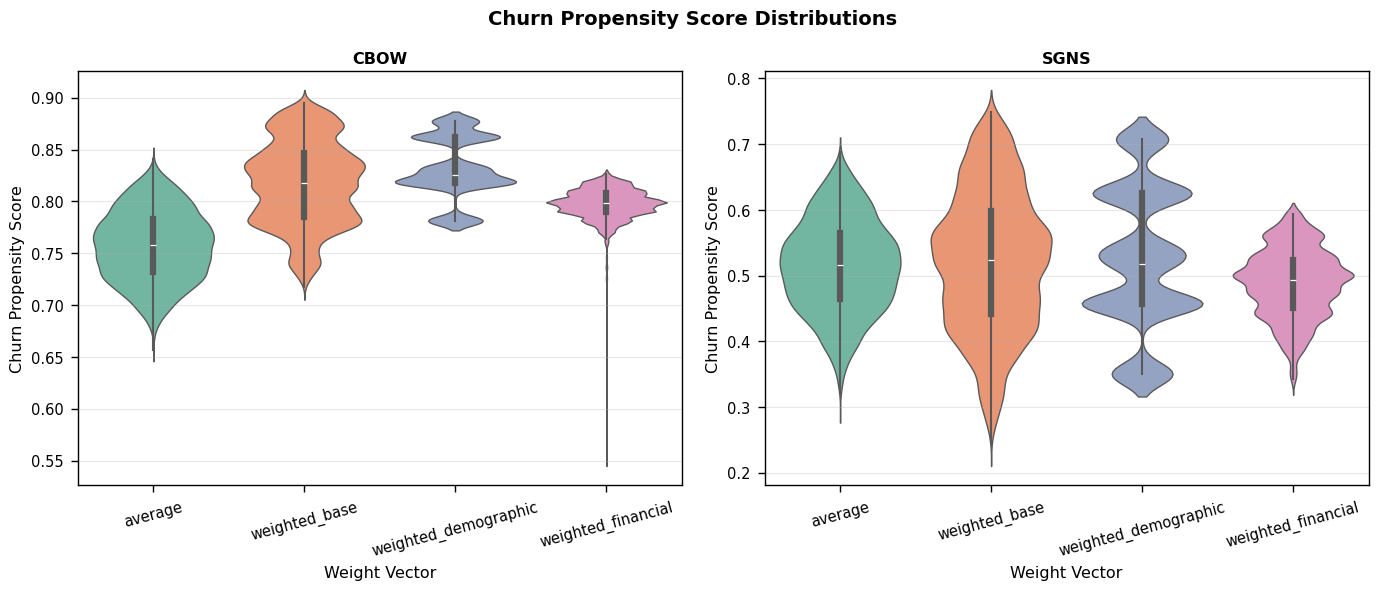

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_churn_score_distributions(
    churn_data: pd.DataFrame,
    figsize: tuple = (14, 6),
    save_path: str = None
):
    """
    Violin/Box Plots der Churn Propensity Scores für verschiedene Weight Vectors.
    """
    # Setup
    plt.style.use('seaborn-v0_8-paper')
    sns.set_context("paper", font_scale=1.2)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('Churn Propensity Score Distributions', 
                 fontsize=14, fontweight='bold')
    
    # Prepare data (reshape to long format)
    score_cols = [c for c in churn_data.columns if c.startswith('ChurnProp_')]
    
    for ax, model in zip(axes, churn_data['model'].unique()):
        model_data = churn_data[churn_data['model'] == model]
        
        plot_data = []
        for score_col in score_cols:
            weight = score_col.replace('ChurnProp_', '')
            scores = model_data[score_col].dropna()
            
            for score in scores:
                plot_data.append({
                    'Weight Vector': weight,
                    'Churn Propensity Score': score
                })
        
        plot_df = pd.DataFrame(plot_data)
        
        # Violin plot
        sns.violinplot(
            data=plot_df,
            x='Weight Vector',
            y='Churn Propensity Score',
            ax=ax,
            palette='Set2',
            inner='box'
        )
        
        ax.set_title(f'{model}', fontweight='bold')
        ax.set_xlabel('Weight Vector')
        ax.set_ylabel('Churn Propensity Score')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=15)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    return fig


# Generiere Plot
fig1 = plot_churn_score_distributions(
    churn_data=churn_data,
    save_path='churn_score_distributions.png'
)
plt.show()

Saved to: churn_ranking_overlap.png


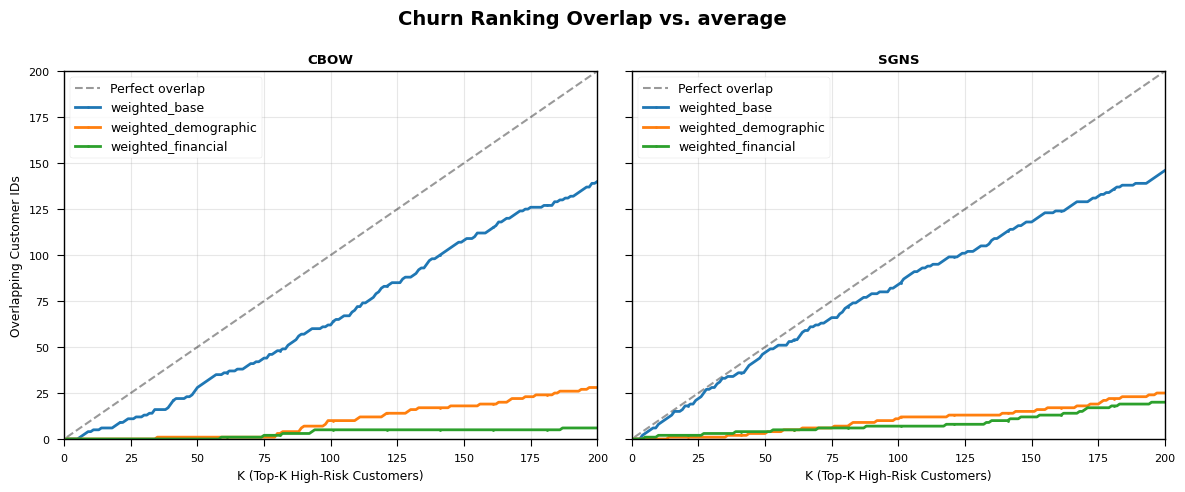

In [13]:
def plot_churn_ranking_overlap_curves(
    churn_data: pd.DataFrame,
    baseline_weight: str = 'average',
    k_max: int = 200,
    figsize: tuple = (12, 5),
    save_path: str = None
):
    """
    Overlap Curves für Churn Rankings (analog zu Scenario A).
    """
    plt.style.use('seaborn-v0_8-paper')
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    fig.suptitle(f'Churn Ranking Overlap vs. {baseline_weight}', 
                 fontsize=14, fontweight='bold')
    
    k_range = range(1, k_max + 1)
    
    for ax, model in zip(axes, churn_data['model'].unique()):
        model_data = churn_data[churn_data['model'] == model].copy()
        
        # Baseline IDs
        baseline_rank_col = f'Rank_{baseline_weight}'
        
        # Andere Weight Vectors
        weight_vectors = [c.replace('Rank_', '') 
                         for c in model_data.columns 
                         if c.startswith('Rank_') and c != baseline_rank_col]
        
        # Perfect overlap line
        ax.plot(k_range, k_range, 'k--', linewidth=1.5, alpha=0.4,
               label='Perfect overlap')
        
        for weight in weight_vectors:
            rank_col = f'Rank_{weight}'
            
            overlaps = []
            for k in k_range:
                baseline_set = set(
                    model_data.nsmallest(k, baseline_rank_col)['Kunde_ID']
                )
                other_set = set(
                    model_data.nsmallest(k, rank_col)['Kunde_ID']
                )
                overlap = len(baseline_set.intersection(other_set))
                overlaps.append(overlap)
            
            ax.plot(k_range, overlaps, linewidth=2, 
                   label=weight, marker='o', markersize=2, markevery=20)
        
        ax.set_xlabel('K (Top-K High-Risk Customers)')
        if ax == axes[0]:
            ax.set_ylabel('Overlapping Customer IDs')
        ax.set_title(f'{model}', fontweight='bold')
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, k_max)
        ax.set_ylim(0, k_max)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    return fig


# Generiere Plot
fig2 = plot_churn_ranking_overlap_curves(
    churn_data=churn_data,
    baseline_weight='average',
    k_max=200,
    save_path='churn_ranking_overlap.png'
)
plt.show()

Saved to: churn_precision_heatmap.png


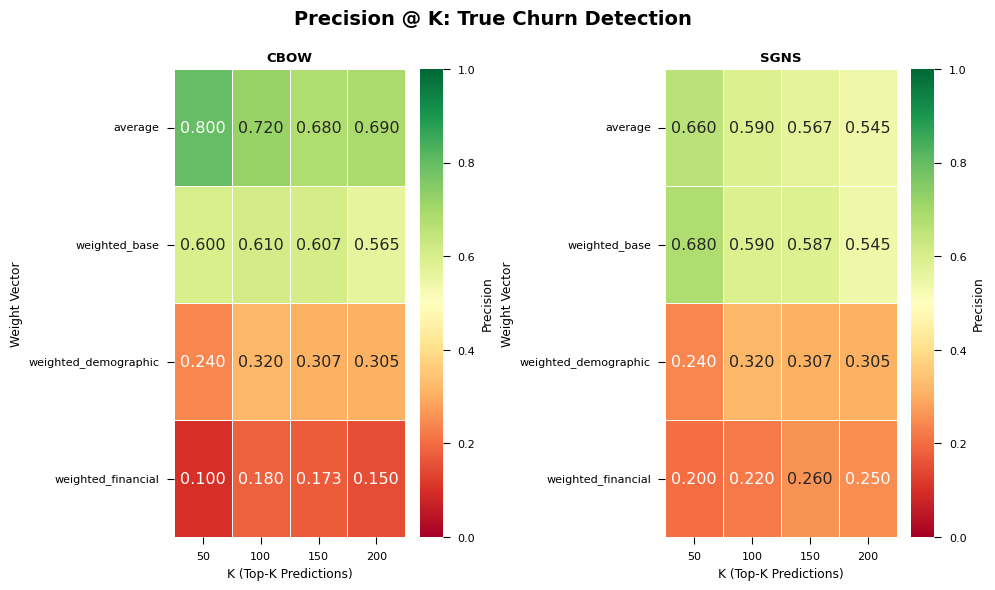

In [14]:
def plot_precision_at_k_heatmap(
    precision_df: pd.DataFrame,
    figsize: tuple = (10, 6),
    save_path: str = None
):
    """
    Heatmap: Wie gut identifiziert jeder Weight Vector echte Churns?
    """
    plt.style.use('seaborn-v0_8-paper')
    
    models = precision_df['model'].unique()
    n_models = len(models)
    
    fig, axes = plt.subplots(1, n_models, figsize=figsize)
    if n_models == 1:
        axes = [axes]
    
    fig.suptitle('Precision @ K: True Churn Detection', 
                 fontsize=14, fontweight='bold')
    
    for ax, model in zip(axes, models):
        model_data = precision_df[precision_df['model'] == model]
        
        # Pivot für Heatmap
        pivot = model_data.pivot_table(
            index='weight_vector',
            columns='K',
            values='precision'
        )
        
        # Heatmap
        sns.heatmap(
            pivot,
            annot=True,
            fmt='.3f',
            cmap='RdYlGn',
            vmin=0,
            vmax=1,
            cbar_kws={'label': 'Precision'},
            linewidths=0.5,
            ax=ax
        )
        
        ax.set_title(f'{model}', fontweight='bold')
        ax.set_xlabel('K (Top-K Predictions)')
        ax.set_ylabel('Weight Vector')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    return fig


# Generiere Plot
fig3 = plot_precision_at_k_heatmap(
    precision_df=precision_df,
    save_path='churn_precision_heatmap.png'
)
plt.show()

Saved to: churn_score_vs_rank.png


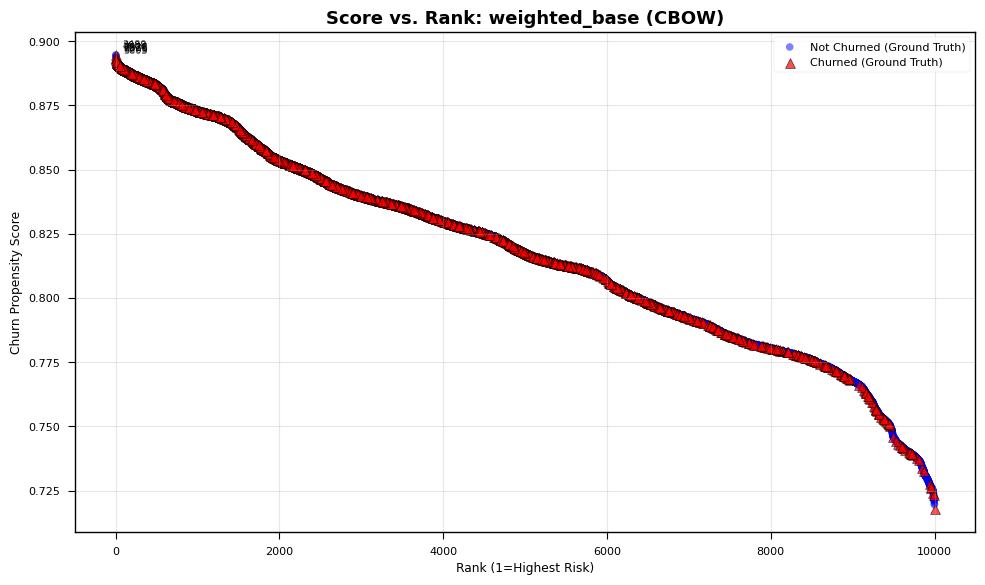

In [15]:
def plot_score_vs_rank_with_ground_truth(
    churn_data: pd.DataFrame,
    weight_vector: str = 'weighted_base',
    model: str = 'CBOW',
    figsize: tuple = (10, 6),
    save_path: str = None
):
    """
    Scatter Plot: Churn Score vs. Rank, farbcodiert nach Ground Truth.
    Zeigt ob hochgerankete Kunden tatsächlich churnen.
    """
    plt.style.use('seaborn-v0_8-paper')
    
    fig, ax = plt.subplots(figsize=figsize)
    
    model_data = churn_data[churn_data['model'] == model].copy()
    
    score_col = f'ChurnProp_{weight_vector}'
    rank_col = f'Rank_{weight_vector}'
    
    # Separate nach Ground Truth
    churned = model_data[model_data['churn'] == 1]
    not_churned = model_data[model_data['churn'] == 0]
    
    # Scatter
    ax.scatter(not_churned[rank_col], not_churned[score_col],
              alpha=0.5, s=30, c='blue', label='Not Churned (Ground Truth)',
              edgecolors='none')
    
    ax.scatter(churned[rank_col], churned[score_col],
              alpha=0.7, s=50, c='red', label='Churned (Ground Truth)',
              edgecolors='black', linewidth=0.5, marker='^')
    
    ax.set_xlabel(f'Rank (1=Highest Risk)')
    ax.set_ylabel('Churn Propensity Score')
    ax.set_title(f'Score vs. Rank: {weight_vector} ({model})',
                fontweight='bold', fontsize=13)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Annotate Top-10
    top10 = model_data.nsmallest(10, rank_col)
    for _, row in top10.iterrows():
        ax.annotate(
            f"{int(row['Kunde_ID'])}",
            (row[rank_col], row[score_col]),
            fontsize=7, alpha=0.6,
            xytext=(5, 5), textcoords='offset points'
        )
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    return fig


# Generiere Plot
fig4 = plot_score_vs_rank_with_ground_truth(
    churn_data=churn_data,
    weight_vector='weighted_base',
    model='CBOW',
    save_path='churn_score_vs_rank.png'
)
plt.show()

Saved to: churn_model_comparison.png


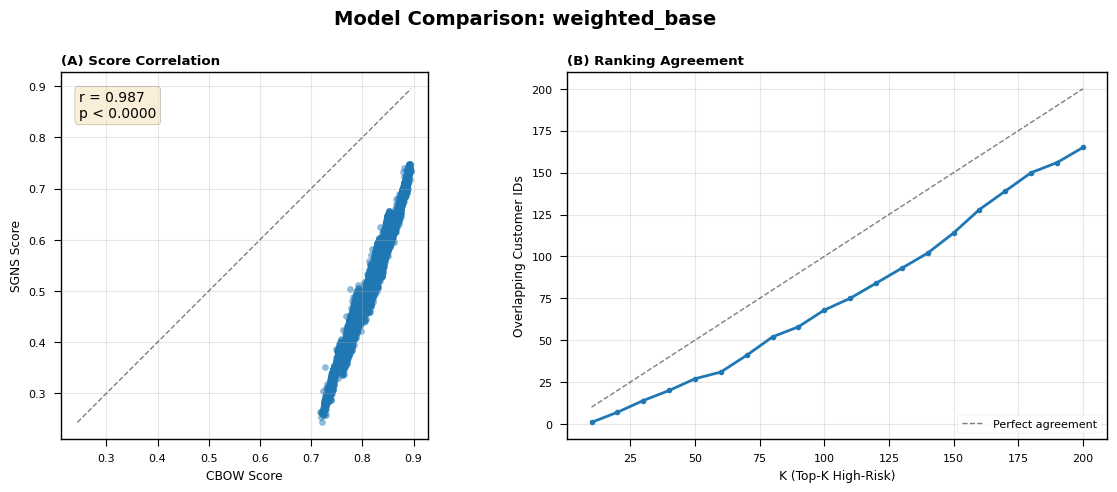

In [16]:
def plot_churn_model_comparison(
    churn_data: pd.DataFrame,
    weight_vector: str = 'weighted_base',
    figsize: tuple = (12, 5),
    save_path: str = None
):
    """
    Vergleicht Churn Rankings zwischen CBOW und SGNS.
    """
    plt.style.use('seaborn-v0_8-paper')
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f'Model Comparison: {weight_vector}', 
                 fontsize=14, fontweight='bold')
    
    models = churn_data['model'].unique()
    if len(models) != 2:
        print("Benötigt genau 2 Modelle für Vergleich")
        return None
    
    score_col = f'ChurnProp_{weight_vector}'
    rank_col = f'Rank_{weight_vector}'
    
    # Panel A: Score Correlation
    ax = axes[0]
    
    model1_data = churn_data[churn_data['model'] == models[0]].set_index('Kunde_ID')[score_col]
    model2_data = churn_data[churn_data['model'] == models[1]].set_index('Kunde_ID')[score_col]
    
    # Merge
    merged = pd.DataFrame({
        models[0]: model1_data,
        models[1]: model2_data
    }).dropna()
    
    ax.scatter(merged[models[0]], merged[models[1]], alpha=0.5, s=20)
    
    # Perfect correlation line
    lims = [
        min(merged[models[0]].min(), merged[models[1]].min()),
        max(merged[models[0]].max(), merged[models[1]].max())
    ]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1)
    
    # Correlation coefficient
    from scipy.stats import pearsonr
    corr, p_val = pearsonr(merged[models[0]], merged[models[1]])
    
    ax.text(0.05, 0.95, f'r = {corr:.3f}\np < {p_val:.4f}',
           transform=ax.transAxes, fontsize=10,
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel(f'{models[0]} Score')
    ax.set_ylabel(f'{models[1]} Score')
    ax.set_title('(A) Score Correlation', fontweight='bold', loc='left')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Panel B: Rank Agreement (Top-K overlap)
    ax = axes[1]
    
    k_range = range(10, 201, 10)
    overlaps = []
    
    model1_ranks = churn_data[churn_data['model'] == models[0]]
    model2_ranks = churn_data[churn_data['model'] == models[1]]
    
    for k in k_range:
        top_k_m1 = set(model1_ranks.nsmallest(k, rank_col)['Kunde_ID'])
        top_k_m2 = set(model2_ranks.nsmallest(k, rank_col)['Kunde_ID'])
        
        overlap = len(top_k_m1.intersection(top_k_m2))
        overlaps.append(overlap)
    
    ax.plot(k_range, overlaps, linewidth=2, marker='o', markersize=4)
    ax.plot(k_range, k_range, 'k--', alpha=0.5, linewidth=1,
           label='Perfect agreement')
    
    ax.set_xlabel('K (Top-K High-Risk)')
    ax.set_ylabel('Overlapping Customer IDs')
    ax.set_title('(B) Ranking Agreement', fontweight='bold', loc='left')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    return fig


# Generiere Plot
fig5 = plot_churn_model_comparison(
    churn_data=churn_data,
    weight_vector='weighted_base',
    save_path='churn_model_comparison.png'
)
plt.show()

In [17]:
def generate_complete_scenario_b_report(
    results: dict,
    model_map: dict = None,
    original_df: pd.DataFrame = None,
    output_dir: str = './figures_scenario_b',
    k_max: int = 200
):
    """
    Generiert alle Churn-Visualisierungen mit einem Aufruf.
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    print("="*70)
    print("GENERATING SCENARIO B: CHURN PROPENSITY REPORT")
    print("="*70)
    
    # Extract data
    print("\n[1/6] Extracting churn propensity data...")
    churn_data = extract_churn_propensity_data(
        results=results,
        model_map=model_map,
        original_df=original_df
    )
    print(f"  - Shape: {churn_data.shape}")
    print(f"  - Models: {churn_data['model'].unique()}")
    
    # Compute metrics
    print("\n[2/6] Computing evaluation metrics...")
    precision_df = compute_precision_at_k(
        churn_data=churn_data,
        k_values=[50, 100, 150, 200]
    )
    print(f"  - Precision@K computed for {len(precision_df)} configurations")
    
    # Generate plots
    print("\n[3/6] Generating score distribution plots...")
    fig1 = plot_churn_score_distributions(
        churn_data=churn_data,
        save_path=f"{output_dir}/01_churn_score_distributions.png"
    )
    plt.close(fig1)
    
    print("\n[4/6] Generating ranking overlap curves...")
    fig2 = plot_churn_ranking_overlap_curves(
        churn_data=churn_data,
        baseline_weight='average',
        k_max=k_max,
        save_path=f"{output_dir}/02_churn_ranking_overlap.png"
    )
    plt.close(fig2)
    
    print("\n[5/6] Generating precision@K heatmap...")
    fig3 = plot_precision_at_k_heatmap(
        precision_df=precision_df,
        save_path=f"{output_dir}/03_churn_precision_heatmap.png"
    )
    plt.close(fig3)
    
    print("\n[6/6] Generating score vs rank scatter...")
    for weight in ['average', 'weighted_base', 'weighted_demographic', 'weighted_financial']:
        for model in churn_data['model'].unique():
            try:
                fig = plot_score_vs_rank_with_ground_truth(
                    churn_data=churn_data,
                    weight_vector=weight,
                    model=model,
                    save_path=f"{output_dir}/04_scatter_{weight}_{model}.png"
                )
                plt.close(fig)
            except:
                print(f"  - Skipped: {weight} / {model}")
    
    print("\n[BONUS] Generating model comparison...")
    try:
        fig5 = plot_churn_model_comparison(
            churn_data=churn_data,
            weight_vector='weighted_base',
            save_path=f"{output_dir}/05_churn_model_comparison.png"
        )
        plt.close(fig5)
    except Exception as e:
        print(f"  - Model comparison skipped: {e}")
    
    # Export data
    print("\n[DATA EXPORT]")
    churn_data.to_csv(f"{output_dir}/churn_propensity_data.csv", index=False)
    precision_df.to_csv(f"{output_dir}/precision_at_k.csv", index=False)
    print(f"  - Exported churn_propensity_data.csv")
    print(f"  - Exported precision_at_k.csv")
    
    print("\n" + "="*70)
    print(f"SCENARIO B REPORT COMPLETE: {output_dir}/")
    print("="*70)


# ===== USAGE =====
generate_complete_scenario_b_report(
    results=results_with_churn,
    model_map={0: "CBOW", 1: "SGNS"},
    original_df=df_collection["formated_table_with_keys"],
    output_dir='./figures_scenario_b',
    k_max=200
)

GENERATING SCENARIO B: CHURN PROPENSITY REPORT

[1/6] Extracting churn propensity data...
  - Shape: (20000, 18)
  - Models: ['CBOW' 'SGNS']

[2/6] Computing evaluation metrics...
  - Precision@K computed for 32 configurations

[3/6] Generating score distribution plots...


/tmp/ipykernel_528/2964365876.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_528/2964365876.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Saved to: ./figures_scenario_b/01_churn_score_distributions.png

[4/6] Generating ranking overlap curves...
Saved to: ./figures_scenario_b/02_churn_ranking_overlap.png

[5/6] Generating precision@K heatmap...
Saved to: ./figures_scenario_b/03_churn_precision_heatmap.png

[6/6] Generating score vs rank scatter...
Saved to: ./figures_scenario_b/04_scatter_average_CBOW.png
Saved to: ./figures_scenario_b/04_scatter_average_SGNS.png
Saved to: ./figures_scenario_b/04_scatter_weighted_base_CBOW.png
Saved to: ./figures_scenario_b/04_scatter_weighted_base_SGNS.png
Saved to: ./figures_scenario_b/04_scatter_weighted_demographic_CBOW.png
Saved to: ./figures_scenario_b/04_scatter_weighted_demographic_SGNS.png
Saved to: ./figures_scenario_b/04_scatter_weighted_financial_CBOW.png
Saved to: ./figures_scenario_b/04_scatter_weighted_financial_SGNS.png

[BONUS] Generating model comparison...
Saved to: ./figures_scenario_b/05_churn_model_comparison.png

[DATA EXPORT]
  - Exported churn_propensity_data.csv